In [ ]:
# ----------------------------
# IMPORTS + CONFIG
# ----------------------------

import re
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    r2_score,
    roc_auc_score,
    silhouette_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler
from sklearn.tree import plot_tree
from xgboost import XGBClassifier, XGBRegressor

# ============================================================
# SETTINGS
# ============================================================

pd.set_option(
    'display.float_format',
    '{:.2f}'.format
)


PROJECT_ROOT = Path.cwd().parent

CONFIG = {
    "features_dir": PROJECT_ROOT / "01_data" / "03_features",
    "input_file": "llm_sustainability_strict_v1-2-0_dataframe.csv",
    "output_file": "llm_sustainability_strict_v1-3-0_dataframe.csv",
    "embeddings_file": "llm_sustainability_strict_v1-1-0_embeddings.npy",
    "random_state": 42,
}

INPUT_PATH = CONFIG["features_dir"] / CONFIG["input_file"]
OUTPUT_PATH = CONFIG["features_dir"] / CONFIG["output_file"]
EMBEDDINGS_PATH = CONFIG["features_dir"] / CONFIG["embeddings_file"]

print("INPUT_PATH:", INPUT_PATH)
print("OUTPUT_PATH:", OUTPUT_PATH)
print("EMBEDDINGS_PATH:", EMBEDDINGS_PATH)

INPUT_PATH: c:\Users\heike\Desktop\Stackfuel\Portfolio\llm-sustainability-analysis\01_data\03_features\llm_sustainability_strict_v1-2-0_dataframe.csv
OUTPUT_PATH: c:\Users\heike\Desktop\Stackfuel\Portfolio\llm-sustainability-analysis\01_data\03_features\llm_sustainability_strict_v1-3-0_dataframe.csv
EMBEDDINGS_PATH: c:\Users\heike\Desktop\Stackfuel\Portfolio\llm-sustainability-analysis\01_data\03_features\llm_sustainability_strict_v1-1-0_embeddings.npy


In [14]:
# ----------------------------
# IO HELPERS
# ----------------------------

def load_csv(INPUT_PATH):
    with Path(INPUT_PATH).open("r", encoding="utf-8") as file:
        return pd.read_csv(file)

def load_emb(EMBEDDINGS_PATH):
    with Path(EMBEDDINGS_PATH).open("rb") as file:
        return np.load(file)

def save_csv(df, OUTPUT_PATH):
    path = Path(OUTPUT_PATH)
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(path, index=False)


In [15]:
# ----------------------------
# LOAD DATA
# ----------------------------

embeddings = load_emb(EMBEDDINGS_PATH)

df = load_csv(INPUT_PATH)

print("Input path:", INPUT_PATH)
print("Exists:", INPUT_PATH.exists())
print("Shape:", df.shape)
print("Embeddings shape:", embeddings.shape)

df.head()

Input path: c:\Users\heike\Desktop\Stackfuel\Portfolio\llm-sustainability-analysis\01_data\03_features\llm_sustainability_strict_v1-2-0_dataframe.csv
Exists: True
Shape: (46429, 31)
Embeddings shape: (46429, 384)


,conversation_id,first_prompt,first_response,first_prompt_tokens,first_response_tokens,total_turns,interaction_rounds,total_user_prompts,followup_prompts,needs_follow_up,...,is_valid_prompt,topic,topic_prob,topic_label,topic_cat,embedding_novelty,target_cost,target_success_refusal,target_needs_clarification,log_target_cost
0,QWJhYvA,Summarize the main ideas of Jeff Walker's Prod...,<div><p>Here are the main ideas of Jeff Walker...,34,304,12,6.00,6,5,1,...,1,0,1.00,0_write_like_chatgpt_want_use,general,0.55,304,1,0,5.72
1,i6IyJda,How to tell if a customer segment is well segm...,"<div class=""markdown prose w-full break-words ...",17,113,2,1.00,1,0,0,...,1,-1,0.52,-1_like_use_data_write_time,noise,0.78,113,1,0,4.74
2,A5AbcES,"In Java, I want to replace string like ""This i...","<div class=""markdown prose w-full break-words ...",62,1468,2,1.00,1,0,0,...,1,-1,0.51,-1_like_use_data_write_time,noise,0.96,1468,1,0,7.29
3,hRPPgZT,Metaphorical language is also used to describe...,<div><p>Metaphorical language has been summone...,90,132,22,11.00,11,10,1,...,1,-1,0.76,-1_like_use_data_write_time,noise,0.73,132,1,0,4.89
4,KXxu9my,The following is the job of the hosting servic...,"<div class=""markdown prose w-full break-words ...",507,1014,10,5.00,5,4,1,...,1,0,1.00,0_write_like_chatgpt_want_use,general,0.59,1014,1,0,6.92


In [16]:
df.columns

Index(['conversation_id', 'first_prompt', 'first_response',
       'first_prompt_tokens', 'first_response_tokens', 'total_turns',
       'interaction_rounds', 'total_user_prompts', 'followup_prompts',
       'needs_follow_up', 'total_user_tokens', 'total_assistant_tokens',
       'total_tokens', 'log_total_tokens', 'has_role_instruction',
       'has_audience_or_level_instruction', 'has_format_instruction',
       'question_count', 'prompt_style', 'task_type',
       'orthographic_error_rate', 'is_valid_prompt', 'topic', 'topic_prob',
       'topic_label', 'topic_cat', 'embedding_novelty', 'target_cost',
       'target_success_refusal', 'target_needs_clarification',
       'log_target_cost'],
      dtype='str')

In [17]:
df.dtypes

conversation_id                          str
first_prompt                             str
first_response                           str
first_prompt_tokens                    int64
first_response_tokens                  int64
total_turns                            int64
interaction_rounds                   float64
total_user_prompts                     int64
followup_prompts                       int64
needs_follow_up                        int64
total_user_tokens                      int64
total_assistant_tokens                 int64
total_tokens                           int64
log_total_tokens                     float64
has_role_instruction                   int64
has_audience_or_level_instruction      int64
has_format_instruction                 int64
question_count                         int64
prompt_style                             str
task_type                                str
orthographic_error_rate              float64
is_valid_prompt                        int64
topic     

In [22]:
# dtypes

df["prompt_style"]=df["prompt_style"].astype("category")
df["task_type"]=df["task_type"].astype("category")
df["topic_label"]=df["topic_label"].astype("category")
df["topic_cat"]=df["topic_cat"].astype("category")


df["target_success_refusal"]=df["target_success_refusal"].astype("int")
df["target_needs_clarification"]=df["target_needs_clarification"].astype("int")

df.dtypes

conversation_id                           str
first_prompt                              str
first_response                            str
first_prompt_tokens                     int64
first_response_tokens                   int64
total_turns                             int64
interaction_rounds                    float64
total_user_prompts                      int64
followup_prompts                        int64
needs_follow_up                         int64
total_user_tokens                       int64
total_assistant_tokens                  int64
total_tokens                            int64
log_total_tokens                      float64
has_role_instruction                    int64
has_audience_or_level_instruction       int64
has_format_instruction                  int64
question_count                          int64
prompt_style                         category
task_type                            category
orthographic_error_rate               float64
is_valid_prompt                   

In [31]:
# ----------------------------
# FEATURE / TARGET SPLIT
# ----------------------------

FEATURE_COLUMNS = [
    "conversation_id",
    "first_prompt",
    "first_response",
    "first_prompt_tokens",
    "first_response_tokens",
    "total_turns",
    "interaction_rounds",
    "total_user_prompts",
    "needs_follow_up",
    "total_user_tokens",
    "total_assistant_tokens",
    "total_tokens",
    "log_total_tokens",
    "has_role_instruction",
    "has_audience_or_level_instruction",
    "has_format_instruction",
    "question_count",
    "prompt_style",
    "task_type",
    "orthographic_error_rate",
    "is_valid_prompt",
    "topic",
    "topic_cat",
    "topic_prob",
    "topic_label",
    "embedding_novelty",
]

TARGET_COLUMNS = [
    "conversation_id",
    "target_cost",
    "log_target_cost",
    "target_success_refusal",
    "target_needs_clarification"
]

df_features = df[FEATURE_COLUMNS].copy()
df_target = df[TARGET_COLUMNS].copy()

In [32]:
# ----------------------------
# FEATURE GROUPS
# ----------------------------

central_features = [
    "first_prompt_tokens",
    "has_role_instruction",
    "has_audience_or_level_instruction",
    "has_format_instruction",
    "question_count",
    "prompt_style",
    "task_type",
    "orthographic_error_rate",
    "topic_prob",
    "topic_cat", 
    "embedding_novelty",
]

high_cardinality_features = [
    "topic_label",
]

targets = [
    "target_cost",
    "log_target_cost",
    "target_success_refusal",
    "target_needs_clarification",
]    

numeric_features = [
    "first_prompt_tokens",
    "question_count",
    "orthographic_error_rate",
    "target_cost",
    "topic_prob", 
    "embedding_novelty",
]

binary_features = [
    "has_role_instruction",
    "has_audience_or_level_instruction",
    "has_format_instruction",
    "target_success_refusal",
    "target_needs_clarification",
]

categorical_features = [
    "prompt_style",
    "task_type",
    "topic_cat",
]

id_text_columns = [
    "conversation_id",
    "first_prompt",
    "first_response",
]

print("Central features:", central_features)
print("High-cardinality features:", high_cardinality_features)
print("Target features:", target_features)

Central features: ['first_prompt_tokens', 'has_role_instruction', 'has_audience_or_level_instruction', 'has_format_instruction', 'question_count', 'prompt_style', 'task_type', 'orthographic_error_rate', 'topic_prob', 'topic_cat', 'embedding_novelty']
High-cardinality features: ['topic_label']
Target features: ['target_cost', 'target_success_refusal', 'target_needs_clarification']


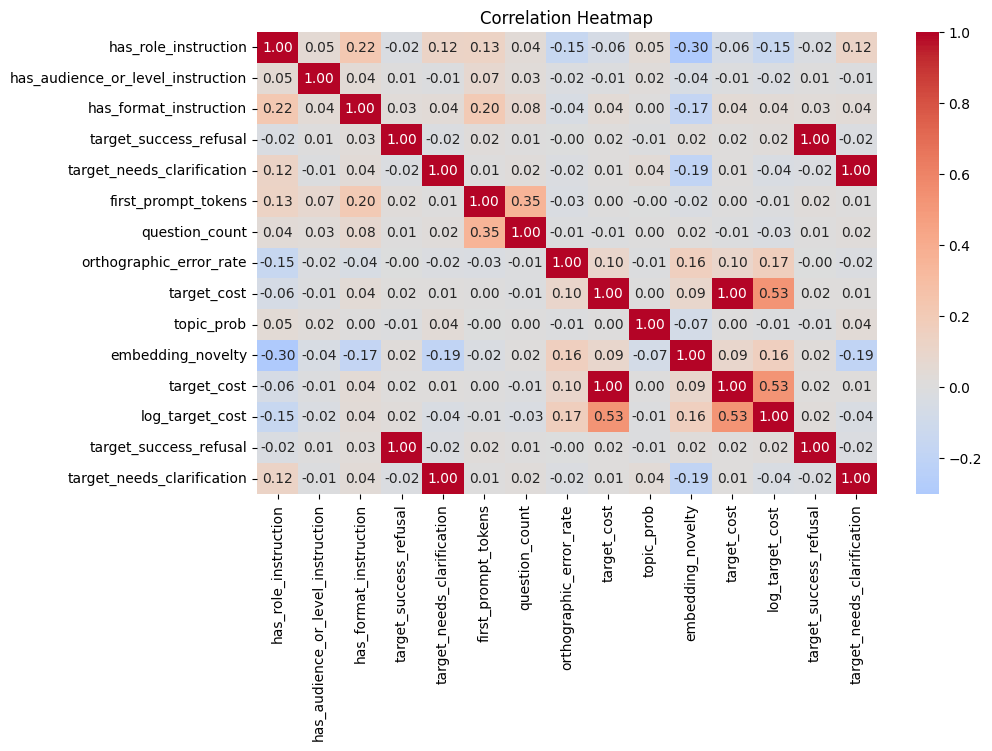

In [33]:
# ----------------------------
# CORRELATIONS
# ----------------------------

features_for_corr = binary_features + numeric_features + targets

corr = df[features_for_corr].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

# train test split

In [ ]:
df_train, df_test = train_test_split(df, test_size=0.2, random_state=42)

features_train_emb = embeddings[df_train.index]
features_test_emb  = embeddings[df_test.index]

In [9]:
df.columns

Index(['conversation_id', 'first_prompt', 'first_response',
       'first_prompt_tokens', 'first_response_tokens', 'total_turns',
       'interaction_rounds', 'total_user_tokens', 'total_assistant_tokens',
       'total_tokens', 'log_total_tokens', 'follow_up_prompts',
       'needs_follow_up', 'has_role_instruction',
       'has_audience_or_level_instruction', 'has_format_instruction',
       'question_count', 'prompt_style', 'task_type',
       'orthographic_error_rate', 'topic', 'topic_prob', 'topic_label',
       'embedding_novelty', 'topic_confidence', 'is_generic_topic',
       'topic_size', 'topic_size_log', 'target_cost', 'target_success',
       'topic_name', 'target_cost_log'],
      dtype='str')

# feature selection

In [10]:
# features selection v01
  
FEATURES_SELECTED_v01 = {
    'cat': [
        "task_type",
        "topic_name",
        ],
    'num': [
        "embedding_novelty",
        "topic_prob",
        "orthographic_error_rate",
        "topic_confidence",
        "topic_size_log"
        ],
    'bin': [
        "has_role_instruction",
        "has_audience_or_level_instruction",
        "has_format_instruction",
        ]
}

# drop: question_count, total_turns, interaction_rounds, total_user_tokens, total_assistant_tokens, total_tokens, log_total_tokens

# baseline logistic regression modell "target_success" without embeddings

In [17]:
# flat features dictionary
features_cols = (
    FEATURES_SELECTED_v01['cat']
    + FEATURES_SELECTED_v01['num']
    + FEATURES_SELECTED_v01['bin']
)

# preprocess
preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), FEATURES_SELECTED_v01['num']),
        ("bin", "passthrough", FEATURES_SELECTED_v01['bin']),
        ("cat", OneHotEncoder(handle_unknown="ignore"), FEATURES_SELECTED_v01['cat']),
    ],
    remainder="drop"
)

# model
model_reg_01 = LogisticRegression(random_state=42, max_iter=2000, class_weight="balanced") 

# pipeline
pipeline = Pipeline([
    ("preprocess", preprocess), 
    ("model", model_reg_01)
])

# fit model
pipeline.fit(df_train[features_cols], df_train["target_success"])    

# predict test
target_test_success_pred = pipeline.predict(df_test[features_cols])
target_test_success_proba = pipeline.predict_proba(df_test[features_cols])[:, 1]

# metrics
print("Accuracy:", accuracy_score(df_test["target_success"], target_test_success_pred))
print("f1_score:", f1_score(df_test["target_success"], target_test_success_pred))
print("ROC AUC:", roc_auc_score(df_test["target_success"], target_test_success_proba))

Accuracy: 0.6265426733877977
f1_score: 0.7431713585559739
ROC AUC: 0.677399552040287


In [12]:
# names of features

model = pipeline.named_steps["model"]
preprocess = pipeline.named_steps["preprocess"]

feature_names = preprocess.get_feature_names_out()

coefficients = model.coef_[0]

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
})

coef_df = coef_df.sort_values("coefficient", ascending=False)

print(coef_df.head(40))

                                           feature  coefficient
6           bin__has_audience_or_level_instruction         0.70
14                    cat__task_type_summarization         0.59
24                  cat__topic_name_Travel / Trips         0.52
0                           num__embedding_novelty         0.50
11                      cat__task_type_explanation         0.43
19        cat__topic_name_Git / GitHub Development         0.35
21         cat__topic_name_Medical / Clinical Data         0.34
25                             cat__topic_name_nan         0.31
8                     cat__task_type_brainstorming         0.27
4                              num__topic_size_log         0.19
18               cat__topic_name_Cooking / Recipes         0.13
1                                  num__topic_prob        -0.01
3                            num__topic_confidence        -0.01
2                     num__orthographic_error_rate        -0.01
7                      bin__has_format_i

# global importances

In [13]:
# get names from pipeline
preprocess = pipeline.named_steps["preprocess"]
model = pipeline.named_steps["model"]

features_train_transformed = preprocess.transform(df_train[features_cols])
features_test_transformed = preprocess.transform(df_test[features_cols])

feature_names = preprocess.get_feature_names_out()

# SHAP explainer
explainer = shap.LinearExplainer(
    model,
    features_train_transformed
)

shap_values = explainer(features_test_transformed)


fi_shap = pd.DataFrame({
    "feature": feature_names,
    "importance": np.abs(shap_values.values).mean(axis=0)
}).sort_values("importance", ascending=False)


def original_feature_name(feature):

    # numerische Features
    for col in FEATURES_SELECTED_v01["num"]:
        if feature == f"num__{col}":
            return col

    # binäre Features
    for col in FEATURES_SELECTED_v01["bin"]:
        if feature == f"bin__{col}":
            return col

    # kategorische Features (OHE)
    for col in FEATURES_SELECTED_v01["cat"]:
        if feature.startswith(f"cat__{col}_"):
            return col

    return feature


fi_shap["original_feature"] = (
    fi_shap["feature"]
    .apply(original_feature_name)
)

grouped_importance = (
    fi_shap.groupby("original_feature", as_index=False)["importance"]
           .sum()
           .sort_values("importance", ascending=False)
)

grouped_importance

,original_feature,importance
7,topic_name,0.66
0,embedding_novelty,0.41
5,task_type,0.29
9,topic_size_log,0.11
3,has_role_instruction,0.09
1,has_audience_or_level_instruction,0.01
2,has_format_instruction,0.01
6,topic_confidence,0.01
8,topic_prob,0.01
4,orthographic_error_rate,0.01


# baseline logistic regression modell "target_success" with embeddings

In [14]:
# tabular pipeline
tabular_pipeline = ColumnTransformer( 
    transformers=[ ("num", "passthrough", FEATURES_SELECTED_v01['num']), 
                  ("bin", "passthrough", FEATURES_SELECTED_v01['bin']), 
                  ("cat", OneHotEncoder(handle_unknown="ignore"), 
                   FEATURES_SELECTED_v01['cat']), ], remainder="drop" )

# tabular features
df_train_tab = tabular_pipeline.fit_transform(df_train[features_cols])
df_test_tab = tabular_pipeline.transform(df_test[features_cols])

# add embeddings
features_train = np.hstack([df_train_tab, features_train_emb])
features_test = np.hstack([df_test_tab, features_test_emb])

# initiate model
model_reg_03 = LogisticRegression(random_state=42, max_iter=2000, class_weight="balanced", solver="saga")

# fit modell
model_reg_03.fit(features_train, df_train["target_success"])


# predict
target_test_success_pred = model_reg_03.predict(features_test)
target_test_success_proba = model_reg_03.predict_proba(features_test)[:, 1]


# metrics
print("Accuracy:", accuracy_score(df_test["target_success"], target_test_success_pred))
print("f1_score:", f1_score(df_test["target_success"], target_test_success_pred))
print("ROC AUC:", roc_auc_score(df_test["target_success"], target_test_success_proba))

Accuracy: 0.7079784460281592
f1_score: 0.8066298342541437
ROC AUC: 0.7825604596963263


In [15]:
# names of features

tabular_feature_names = tabular_pipeline.get_feature_names_out()

embedding_feature_names = [
    f"embedding_{i}"
    for i in range(features_train_emb.shape[1])
]

all_feature_names = np.concatenate([
    tabular_feature_names,
    embedding_feature_names
])

coef_df = pd.DataFrame({
    "feature": all_feature_names,
    "coefficient": model_reg_03.coef_[0]
})

coef_df["abs_coefficient"] = coef_df["coefficient"].abs()

coef_df.sort_values("abs_coefficient", ascending=False).head(50)

,feature,coefficient,abs_coefficient
320,embedding_294,3.47,3.47
166,embedding_140,2.91,2.91
44,embedding_18,2.77,2.77
230,embedding_204,2.67,2.67
242,embedding_216,2.64,2.64
337,embedding_311,-2.63,2.63
305,embedding_279,2.60,2.60
131,embedding_105,-2.54,2.54
324,embedding_298,-2.50,2.50
182,embedding_156,-2.41,2.41


# baseline logistic regression modell "target_success" with embeddings and PCA

In [16]:
model_reg_04 = LogisticRegression(
    random_state=42,
    max_iter=2000,
    class_weight="balanced",
    solver="saga"
)

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=0.95)),
    ("clf", model_reg_04)
])

pipeline.fit(features_train_emb)
score = pipeline.score(features_test_emb)

ValueError: This LogisticRegression estimator requires y to be passed, but the target y is None.